# Transformer Models — Full 12-Step Direct Multi-Horizon Forecasting

Two attention-based architectures compared with **12-step direct prediction** (t+1 through t+12, 15min to 3h):
- **Vanilla Transformer Encoder** — timestep tokens, self-attention across time
- **iTransformer** — feature tokens, self-attention across variates (inverted)

Same architectures as the 3-horizon notebook, just HORIZON=12.


In [ ]:
!pip install optuna -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math, random, time, warnings

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## 1. Data Loading (identical to main notebook)

In [ ]:
FILENAME = '/content/Final2026_with_ENTSOE.csv'

try:
    df = pd.read_csv(FILENAME, sep=',')
    if len(df.columns) == 1: df = pd.read_csv(FILENAME, sep=';')
except: df = pd.read_csv(FILENAME)

df = df.rename(columns={
    'Day time': 'DELIVERY_MTU', 'DAM price': 'DAM_MCP',
    'IDA1': 'MCP', 'IDA2': 'MCP_IDA2', 'IDA3': 'MCP_IDA3',
    'BM price': 'BM_IMBALANCE_PRICE', 'BMmDAM price': 'BMmDAMMCP',
})
df['DELIVERY_MTU'] = pd.to_datetime(df['DELIVERY_MTU'])
df = df.sort_values('DELIVERY_MTU').reset_index(drop=True)

df['hour'] = df['DELIVERY_MTU'].dt.hour
df['minute'] = df['DELIVERY_MTU'].dt.minute / 60.0
df['dayofweek'] = df['DELIVERY_MTU'].dt.dayofweek
df['ida3_available'] = df['MCP_IDA3'].notna().astype(float)
df['MCP_IDA3'] = df['MCP_IDA3'].fillna(0.0)
df['MCP_IDA2'] = df['MCP_IDA2'].ffill().bfill().fillna(0.0)
df['MCP'] = df['MCP'].ffill().bfill().fillna(df['MCP_IDA2'])
df['DAM_MCP'] = df['DAM_MCP'].ffill().bfill()
df['BMmDAMMCP'] = df['BMmDAMMCP'].ffill().bfill().fillna(0.0)
df['BM_IMBALANCE_PRICE'] = df['BM_IMBALANCE_PRICE'].ffill().bfill().fillna(df['BM_IMBALANCE_PRICE'].median())
df['IDA_target'] = np.where(df['ida3_available'] == 1, df['MCP_IDA3'], df['MCP_IDA2'])
df['ISP2_RES'] = df['ISP2_RES'].ffill().bfill().fillna(df['ISP1_RES'])
df['ISP2_Load'] = df['ISP2_Load'].ffill().bfill().fillna(df['ISP1_Load'])

df['DA_RES'] = df['Wind_DA_forecast'] + df['Solar_DA_forecast']
is_ida3 = df['hour'] >= 12
df['latest_RES'] = np.where(is_ida3, df['ISP3_RES'], df['ISP2_RES'])
df['latest_Load'] = np.where(is_ida3, df['ISP3_Load'], df['ISP2_Load'])
df['latest_RES_revision'] = df['latest_RES'] - df['DA_RES']
df['latest_Load_revision'] = df['latest_Load'] - df['SystemLoad_DA_forecast']
df['latest_net_load'] = df['latest_Load'] - df['latest_RES']
df['DA_net_load'] = df['SystemLoad_DA_forecast'] - df['DA_RES']
df['latest_net_load_revision'] = df['latest_net_load'] - df['DA_net_load']
df['RES_revision_ISP2_to_ISP3'] = np.where(is_ida3, df['ISP3_RES'] - df['ISP2_RES'], 0.0)
df['Load_revision_ISP2_to_ISP3'] = np.where(is_ida3, df['ISP3_Load'] - df['ISP2_Load'], 0.0)

df['bm_roll_mean_4'] = df['BM_IMBALANCE_PRICE'].rolling(4, min_periods=1).mean()
df['bm_roll_std_4'] = df['BM_IMBALANCE_PRICE'].rolling(4, min_periods=1).std().fillna(0)
df['bm_roll_mean_12'] = df['BM_IMBALANCE_PRICE'].rolling(12, min_periods=1).mean()
df['ida_momentum'] = df['MCP_IDA2'].diff(4).fillna(0)
df['mcp_momentum'] = df['MCP'].diff(4).fillna(0)
df['bm_momentum'] = df['BM_IMBALANCE_PRICE'].diff(4).fillna(0)
df['bm_ida_spread'] = df['BM_IMBALANCE_PRICE'] - df['MCP_IDA2']
df['ida_roll_std_4'] = df['MCP_IDA2'].rolling(4, min_periods=1).std().fillna(0)

# All 12 steps (15min to 3h)
for s in range(1, 13):
    df[f'IDA_target_step{s}'] = df['IDA_target'].shift(-s)
    df[f'ida3_at_step{s}'] = (df['hour'].shift(-s) >= 12).astype(float)

df = df.dropna(subset=[f'IDA_target_step{s}' for s in range(1, 13)]).reset_index(drop=True)
df = df[df['DELIVERY_MTU'] >= '2025-10-02'].copy().reset_index(drop=True)
df = df[df['DELIVERY_MTU'] <= '2026-01-18 23:45:00'].copy().reset_index(drop=True)

FEATURES = [
    'MCP', 'MCP_IDA2', 'DAM_MCP',
    'BM_IMBALANCE_PRICE', 'bm_roll_mean_4', 'bm_roll_std_4', 'bm_roll_mean_12', 'bm_ida_spread',
    'ida_momentum', 'mcp_momentum', 'bm_momentum', 'ida_roll_std_4',
    'SystemLoad_DA_forecast', 'Wind_DA_forecast', 'Solar_DA_forecast',
    'ida3_available', 'ida3_at_step4', 'ida3_at_step8', 'ida3_at_step12',
    'hour', 'minute', 'dayofweek',
    'latest_RES', 'latest_Load',
    'latest_RES_revision', 'latest_Load_revision', 'latest_net_load_revision', 'latest_net_load',
    'RES_revision_ISP2_to_ISP3', 'Load_revision_ISP2_to_ISP3',
]
TARGETS = [f'IDA_target_step{s}' for s in range(1, 13)]
HORIZON = 12; BATCH = 64; TRAIN_RATIO = 0.8
N_FEAT = len(FEATURES)
split_idx = int(len(df) * TRAIN_RATIO)

df[FEATURES] = df[FEATURES].ffill().bfill().fillna(0)

scaler_X = MinMaxScaler()
data_X = df[FEATURES].values.astype(np.float32)
scaler_X.fit(data_X[:split_idx])
data_X_sc = scaler_X.transform(data_X)

scaler_y = MinMaxScaler()
all_tgt = df[TARGETS].values.astype(np.float32)
scaler_y.fit(all_tgt[:split_idx].reshape(-1, 1))
tgt_sc = np.zeros((len(df), HORIZON), dtype=np.float32)
for h in range(HORIZON):
    tgt_sc[:, h] = scaler_y.transform(df[TARGETS[h]].values.astype(np.float32).reshape(-1,1)).flatten()

print(f"Dataset: {df.shape}, Features: {N_FEAT}, Train: {split_idx}, Test: {len(df)-split_idx}")


Dataset: (10464, 63), Features: 30, Train: 8371, Test: 2093


## 2. Model Definitions

### Vanilla Transformer Encoder
Standard approach: each timestep is a token, self-attention captures temporal dependencies.

### iTransformer (Liu et al., ICLR 2024)
Inverted approach: each **feature** is a token (length = lookback). Attention captures **multivariate correlations** instead of temporal correlations. Feed-forward learns nonlinear representations per variate.

In [ ]:
class SeqDataset(Dataset):
    def __init__(self, X, y, lb):
        self.X, self.y, self.lb = X, y, lb
    def __len__(self):
        return len(self.X) - self.lb
    def __getitem__(self, i):
        return (torch.tensor(self.X[i:i+self.lb], dtype=torch.float32),
                torch.tensor(self.y[i+self.lb], dtype=torch.float32))

# ── Positional Encoding ──
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# ── Vanilla Transformer Encoder ──
# Input: (batch, lookback, n_features) → tokens = timesteps
class TransformerForecaster(nn.Module):
    def __init__(self, n_feat, d_model, nhead, n_layers, dim_ff, horizon, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_feat, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu')
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model // 2, horizon))

    def forward(self, x):
        # x: (batch, lookback, n_feat)
        x = self.input_proj(x)          # (batch, lookback, d_model)
        x = self.pos_enc(x)
        x = self.encoder(x)             # (batch, lookback, d_model)
        x = x[:, -1, :]                 # take last timestep
        return self.fc(x)               # (batch, horizon)

# ── iTransformer ──
# INVERTED: tokens = features, each token is the time series of that feature
# Input: (batch, lookback, n_features) → transpose → (batch, n_features, lookback)
class iTransformerForecaster(nn.Module):
    def __init__(self, n_feat, lookback, d_model, nhead, n_layers, dim_ff, horizon, dropout=0.1):
        super().__init__()
        # Each variate token: lookback values → d_model embedding
        self.variate_embed = nn.Linear(lookback, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu')
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        # Project all variate tokens → horizon predictions
        self.fc = nn.Sequential(
            nn.Linear(n_feat * d_model, d_model), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model, horizon))

    def forward(self, x):
        # x: (batch, lookback, n_feat)
        x = x.permute(0, 2, 1)          # (batch, n_feat, lookback) — INVERTED
        x = self.variate_embed(x)        # (batch, n_feat, d_model) — each feature is a token
        x = self.encoder(x)              # (batch, n_feat, d_model) — attention across features
        x = x.flatten(1)                 # (batch, n_feat * d_model)
        return self.fc(x)                # (batch, horizon)

print(f"Models defined. Features: {N_FEAT}")

Models defined. Features: 30


## 3. Training Infrastructure

In [ ]:
def train_model(model, ld_tr, ld_te, epochs, lr, label=""):
    model = model.to(device)
    crit = nn.L1Loss()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_val = float('inf'); best_state = None

    for ep in range(1, epochs+1):
        model.train(); tl = 0
        for X, y in ld_tr:
            X, y = X.to(device), y.to(device)
            opt.zero_grad(); loss = crit(model(X), y); loss.backward(); opt.step()
            tl += loss.item() * X.size(0)
        tl /= len(ld_tr.dataset)

        model.eval(); vl = 0
        with torch.no_grad():
            for X, y in ld_te:
                X, y = X.to(device), y.to(device)
                vl += crit(model(X), y).item() * X.size(0)
        vl /= len(ld_te.dataset)
        sched.step()

        if vl < best_val:
            best_val = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if ep % 30 == 0 or ep == 1:
            print(f"  [{label}] {ep:3d}/{epochs} | train: {tl:.6f} | val: {vl:.6f}")

    model.load_state_dict(best_state)
    print(f"  [{label}] Best: {best_val:.6f}")
    return best_val

def evaluate_model(model, dataset, scaler_y, horizon):
    model.eval()
    preds_all, acts_all = [], []
    with torch.no_grad():
        for X, y in DataLoader(dataset, batch_size=256, shuffle=False):
            preds_all.append(model(X.to(device)).cpu().numpy())
            acts_all.append(y.numpy())
    preds = np.concatenate(preds_all); acts = np.concatenate(acts_all)
    p_inv = np.zeros_like(preds); a_inv = np.zeros_like(acts)
    for h in range(horizon):
        p_inv[:, h] = scaler_y.inverse_transform(preds[:, h].reshape(-1,1)).flatten()
        a_inv[:, h] = scaler_y.inverse_transform(acts[:, h].reshape(-1,1)).flatten()
    return p_inv, a_inv

print("Training infrastructure ready")

Training infrastructure ready


## 4. Optuna — Vanilla Transformer

In [ ]:
SEARCH_EPOCHS = 50

def transformer_objective(trial):
    lb = trial.suggest_categorical('lookback', [24, 48])
    d_model = trial.suggest_categorical('d_model', [32, 64, 128])
    nhead = trial.suggest_categorical('nhead', [2, 4])
    n_layers = trial.suggest_int('n_layers', 1, 3)
    dim_ff = trial.suggest_categorical('dim_ff', [64, 128, 256])
    lr = trial.suggest_float('lr', 1e-4, 3e-3, log=True)
    dropout = trial.suggest_float('dropout', 0.1, 0.3, step=0.1)

    # Ensure d_model divisible by nhead
    if d_model % nhead != 0:
        return float('inf')

    tr = SeqDataset(data_X_sc[:split_idx], tgt_sc[:split_idx], lb)
    te = SeqDataset(data_X_sc[split_idx-lb:], tgt_sc[split_idx-lb:], lb)
    ld_tr = DataLoader(tr, batch_size=BATCH, shuffle=True)
    ld_te = DataLoader(te, batch_size=BATCH, shuffle=False)

    torch.manual_seed(SEED)
    model = TransformerForecaster(N_FEAT, d_model, nhead, n_layers, dim_ff, HORIZON, dropout).to(device)
    crit = nn.L1Loss()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_val = float('inf')
    for ep in range(1, SEARCH_EPOCHS + 1):
        model.train()
        for X, y in ld_tr:
            X, y = X.to(device), y.to(device)
            opt.zero_grad(); loss = crit(model(X), y); loss.backward(); opt.step()
        model.eval(); vl = 0
        with torch.no_grad():
            for X, y in ld_te:
                X, y = X.to(device), y.to(device)
                vl += crit(model(X), y).item() * X.size(0)
        vl /= len(ld_te.dataset)
        if vl < best_val: best_val = vl
        trial.report(vl, ep)
        if trial.should_prune(): raise optuna.TrialPruned()
    return best_val

print("Running Transformer Optuna (30 trials)...")
tf_study = optuna.create_study(direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=15),
    sampler=optuna.samplers.TPESampler(seed=SEED))
tf_study.optimize(transformer_objective, n_trials=30, show_progress_bar=True)
bp_tf = tf_study.best_trial.params
print(f"Transformer best: {bp_tf}, val_loss={tf_study.best_trial.value:.6f}")

Running Transformer Optuna (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

Transformer best: {'lookback': 48, 'd_model': 32, 'nhead': 4, 'n_layers': 2, 'dim_ff': 128, 'lr': 0.0008127122658458551, 'dropout': 0.3}, val_loss=0.027152


## 5. Optuna — iTransformer

In [ ]:
def itransformer_objective(trial):
    lb = trial.suggest_categorical('lookback', [24, 48])
    d_model = trial.suggest_categorical('d_model', [32, 64, 128])
    nhead = trial.suggest_categorical('nhead', [2, 4])
    n_layers = trial.suggest_int('n_layers', 1, 3)
    dim_ff = trial.suggest_categorical('dim_ff', [64, 128, 256])
    lr = trial.suggest_float('lr', 1e-4, 3e-3, log=True)
    dropout = trial.suggest_float('dropout', 0.1, 0.3, step=0.1)

    if d_model % nhead != 0:
        return float('inf')

    tr = SeqDataset(data_X_sc[:split_idx], tgt_sc[:split_idx], lb)
    te = SeqDataset(data_X_sc[split_idx-lb:], tgt_sc[split_idx-lb:], lb)
    ld_tr = DataLoader(tr, batch_size=BATCH, shuffle=True)
    ld_te = DataLoader(te, batch_size=BATCH, shuffle=False)

    torch.manual_seed(SEED)
    model = iTransformerForecaster(N_FEAT, lb, d_model, nhead, n_layers, dim_ff, HORIZON, dropout).to(device)
    crit = nn.L1Loss()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_val = float('inf')
    for ep in range(1, SEARCH_EPOCHS + 1):
        model.train()
        for X, y in ld_tr:
            X, y = X.to(device), y.to(device)
            opt.zero_grad(); loss = crit(model(X), y); loss.backward(); opt.step()
        model.eval(); vl = 0
        with torch.no_grad():
            for X, y in ld_te:
                X, y = X.to(device), y.to(device)
                vl += crit(model(X), y).item() * X.size(0)
        vl /= len(ld_te.dataset)
        if vl < best_val: best_val = vl
        trial.report(vl, ep)
        if trial.should_prune(): raise optuna.TrialPruned()
    return best_val

print("Running iTransformer Optuna (30 trials)...")
it_study = optuna.create_study(direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=15),
    sampler=optuna.samplers.TPESampler(seed=SEED))
it_study.optimize(itransformer_objective, n_trials=30, show_progress_bar=True)
bp_it = it_study.best_trial.params
print(f"iTransformer best: {bp_it}, val_loss={it_study.best_trial.value:.6f}")

Running iTransformer Optuna (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

iTransformer best: {'lookback': 48, 'd_model': 32, 'nhead': 4, 'n_layers': 3, 'dim_ff': 128, 'lr': 0.001757234235013428, 'dropout': 0.3}, val_loss=0.027634


In [ ]:
# Optuna will produce new best params for 12-step target
# (Remove hardcoded params from 3-horizon runs)
print(f"Transformer: {bp_tf}")
print(f"iTransformer: {bp_it}")


## 6. Train Final Models

In [ ]:
EPOCHS = 120
results = {}

# ── Vanilla Transformer ──
print("=" * 60)
print(f"Transformer: {bp_tf}")
lb = bp_tf['lookback']
tr = SeqDataset(data_X_sc[:split_idx], tgt_sc[:split_idx], lb)
te = SeqDataset(data_X_sc[split_idx-lb:], tgt_sc[split_idx-lb:], lb)
torch.manual_seed(SEED)
model_tf = TransformerForecaster(N_FEAT, bp_tf['d_model'], bp_tf['nhead'],
    bp_tf['n_layers'], bp_tf['dim_ff'], HORIZON, bp_tf['dropout'])
train_model(model_tf, DataLoader(tr, batch_size=BATCH, shuffle=True),
            DataLoader(te, batch_size=BATCH, shuffle=False), EPOCHS, bp_tf['lr'], "Transformer")
preds_tf, acts_tf = evaluate_model(model_tf, te, scaler_y, HORIZON)
results['Transformer'] = preds_tf

# ── iTransformer ──
print("=" * 60)
print(f"iTransformer: {bp_it}")
lb = bp_it['lookback']
tr = SeqDataset(data_X_sc[:split_idx], tgt_sc[:split_idx], lb)
te = SeqDataset(data_X_sc[split_idx-lb:], tgt_sc[split_idx-lb:], lb)
torch.manual_seed(SEED)
model_it = iTransformerForecaster(N_FEAT, lb, bp_it['d_model'], bp_it['nhead'],
    bp_it['n_layers'], bp_it['dim_ff'], HORIZON, bp_it['dropout'])
train_model(model_it, DataLoader(tr, batch_size=BATCH, shuffle=True),
            DataLoader(te, batch_size=BATCH, shuffle=False), EPOCHS, bp_it['lr'], "iTransformer")
preds_it, acts_it = evaluate_model(model_it, te, scaler_y, HORIZON)
results['iTransformer'] = preds_it

print("Both models trained.")

Transformer: {'lookback': 48, 'd_model': 32, 'nhead': 4, 'n_layers': 2, 'dim_ff': 128, 'lr': 0.0008127122658458551, 'dropout': 0.3}
  [Transformer]   1/120 | train: 0.117076 | val: 0.040117
  [Transformer]  30/120 | train: 0.033758 | val: 0.028866
  [Transformer]  60/120 | train: 0.031065 | val: 0.028746
  [Transformer]  90/120 | train: 0.029637 | val: 0.029242
  [Transformer] 120/120 | train: 0.029240 | val: 0.029338
  [Transformer] Best: 0.027443
iTransformer: {'lookback': 48, 'd_model': 32, 'nhead': 4, 'n_layers': 3, 'dim_ff': 128, 'lr': 0.001757234235013428, 'dropout': 0.3}
  [iTransformer]   1/120 | train: 0.107724 | val: 0.043465
  [iTransformer]  30/120 | train: 0.030766 | val: 0.028366
  [iTransformer]  60/120 | train: 0.026594 | val: 0.030794
  [iTransformer]  90/120 | train: 0.024799 | val: 0.030543
  [iTransformer] 120/120 | train: 0.024133 | val: 0.030384
  [iTransformer] Best: 0.028209
Both models trained.


## 7. Full Comparison

In [15]:
n_test = min(len(p) for p in results.values())
naive_vals = df['IDA_target'].values[split_idx:split_idx+n_test]

# Full results per model — all 12 steps
print("  FULL 12-STEP DIRECT TRANSFORMER COMPARISON")
print()

for name, preds in results.items():
    acts = acts_tf[-n_test:] if name == 'Transformer' else acts_it[-n_test:]
    preds_c = preds[-n_test:]

    print(f"  === {name} ===")
    print(f"  {'Step':<8} {'Horizon':>8} {'MAE':>8} {'RMSE':>8} {'R2':>7} {'FSI':>7}")
    print(f"  {'-'*55}")
    for h in range(HORIZON):
        horizon_str = f"{(h+1)*15}min"
        mae = mean_absolute_error(acts[:, h], preds_c[:, h])
        rmse = np.sqrt(mean_squared_error(acts[:, h], preds_c[:, h]))
        r2 = r2_score(acts[:, h], preds_c[:, h])
        mae_n = mean_absolute_error(acts[:, h], naive_vals)
        fsi = (1 - mae / mae_n) * 100
        h_label = {4: " (1h)", 8: " (2h)", 12: " (3h)"}.get(h+1, "")
        marker = " <--" if (h+1) in [4, 8, 12] else ""
        print(f"  t+{h+1:<5} {horizon_str:>8} {mae:>8.2f} {rmse:>8.2f} {r2:>7.3f} {fsi:>+6.1f}%{h_label}{marker}")
    print()

# Naive
print(f"  === Naive (persistence) ===")
print(f"  {'Step':<8} {'Horizon':>8} {'MAE':>8} {'RMSE':>8}")
print(f"  {'-'*40}")
acts_ref = acts_tf[-n_test:]
for h in range(HORIZON):
    horizon_str = f"{(h+1)*15}min"
    mae_n = mean_absolute_error(acts_ref[:, h], naive_vals)
    rmse_n = np.sqrt(mean_squared_error(acts_ref[:, h], naive_vals))
    h_label = {4: " (1h)", 8: " (2h)", 12: " (3h)"}.get(h+1, "")
    marker = " <--" if (h+1) in [4, 8, 12] else ""
    print(f"  t+{h+1:<5} {horizon_str:>8} {mae_n:>8.2f} {rmse_n:>8.2f}{h_label}{marker}")

# Side-by-side MAE
print("\n\n  SIDE-BY-SIDE MAE COMPARISON (all 12 steps)")
print(f"  {'Step':<8} {'Minutes':>7}", end="")
for name in results:
    print(f" {name:>14}", end="")
print(f" {'Naive':>10}")
print(f"  {'-'*65}")

for h in range(HORIZON):
    horizon_str = f"{(h+1)*15}min"
    marker = " *" if (h+1) in [4, 8, 12] else ""
    print(f"  t+{h+1:<5} {horizon_str:>7}", end="")
    for name, preds in results.items():
        acts = acts_tf[-n_test:] if name == 'Transformer' else acts_it[-n_test:]
        preds_c = preds[-n_test:]
        mae = mean_absolute_error(acts[:, h], preds_c[:, h])
        print(f" {mae:>14.2f}", end="")
    mae_n = mean_absolute_error(acts_ref[:, h], naive_vals)
    print(f" {mae_n:>10.2f}{marker}")
print("  (* = 1h/2h/3h horizons)")



  FULL 12-STEP DIRECT TRANSFORMER COMPARISON

  === Transformer ===
  Step      Horizon      MAE     RMSE      R2     FSI
  -------------------------------------------------------
  t+1        15min    14.51    22.56   0.700  -44.7%
  t+2        30min    14.88    23.36   0.678  -16.3%
  t+3        45min    15.08    23.85   0.665   +1.9%
  t+4        60min    15.81    24.63   0.642   +8.9% (1h) <--
  t+5        75min    16.31    25.48   0.617  +17.1%
  t+6        90min    16.72    26.07   0.599  +23.6%
  t+7       105min    16.96    26.51   0.586  +28.5%
  t+8       120min    17.42    26.72   0.579  +31.8% (2h) <--
  t+9       135min    17.63    27.04   0.569  +35.0%
  t+10      150min    17.74    27.38   0.558  +38.3%
  t+11      165min    17.99    27.69   0.548  +40.5%
  t+12      180min    18.27    28.08   0.535  +41.9% (3h) <--

  === iTransformer ===
  Step      Horizon      MAE     RMSE      R2     FSI
  -------------------------------------------------------
  t+1        15min   

In [16]:
test_hours = df['hour'].values[split_idx:split_idx+n_test]
ida2_mask = test_hours < 12
ida3_mask = test_hours >= 12

print("  IDA2 (hours < 12) vs IDA3 (hours >= 12) - MAE at all 12 steps")
print()

for name, preds in results.items():
    acts = acts_tf[-n_test:] if name == 'Transformer' else acts_it[-n_test:]
    preds_c = preds[-n_test:]

    print(f"  === {name} ===")
    print(f"  {'Step':<8} {'Horizon':>8} {'IDA2 MAE':>10} {'IDA3 MAE':>10}")
    print(f"  {'-'*42}")
    for h in range(HORIZON):
        horizon_str = f"{(h+1)*15}min"
        m2 = mean_absolute_error(acts[ida2_mask, h], preds_c[ida2_mask, h])
        m3 = mean_absolute_error(acts[ida3_mask, h], preds_c[ida3_mask, h])
        h_label = {4: " (1h)", 8: " (2h)", 12: " (3h)"}.get(h+1, "")
        print(f"  t+{h+1:<5} {horizon_str:>8} {m2:>10.2f} {m3:>10.2f}{h_label}")
    print()

# Naive
acts_ref = acts_tf[-n_test:]
print(f"  === Naive ===")
print(f"  {'Step':<8} {'Horizon':>8} {'IDA2 MAE':>10} {'IDA3 MAE':>10}")
print(f"  {'-'*42}")
for h in range(HORIZON):
    horizon_str = f"{(h+1)*15}min"
    m2 = mean_absolute_error(acts_ref[ida2_mask, h], naive_vals[ida2_mask])
    m3 = mean_absolute_error(acts_ref[ida3_mask, h], naive_vals[ida3_mask])
    h_label = {4: " (1h)", 8: " (2h)", 12: " (3h)"}.get(h+1, "")
    print(f"  t+{h+1:<5} {horizon_str:>8} {m2:>10.2f} {m3:>10.2f}{h_label}")



  IDA2 (hours < 12) vs IDA3 (hours >= 12) - MAE at all 12 steps

  === Transformer ===
  Step      Horizon   IDA2 MAE   IDA3 MAE
  ------------------------------------------
  t+1        15min      10.45      18.50
  t+2        30min      10.93      18.76
  t+3        45min      11.61      18.49
  t+4        60min      12.40      19.15 (1h)
  t+5        75min      13.08      19.48
  t+6        90min      13.71      19.67
  t+7       105min      14.28      19.60
  t+8       120min      14.80      20.00 (2h)
  t+9       135min      15.23      19.98
  t+10      150min      15.58      19.86
  t+11      165min      16.23      19.72
  t+12      180min      16.91      19.61 (3h)

  === iTransformer ===
  Step      Horizon   IDA2 MAE   IDA3 MAE
  ------------------------------------------
  t+1        15min      11.61      19.88
  t+2        30min      11.82      19.47
  t+3        45min      12.24      19.57
  t+4        60min      13.01      20.40 (1h)
  t+5        75min      13.55      20.3

## 8. Prediction Plots

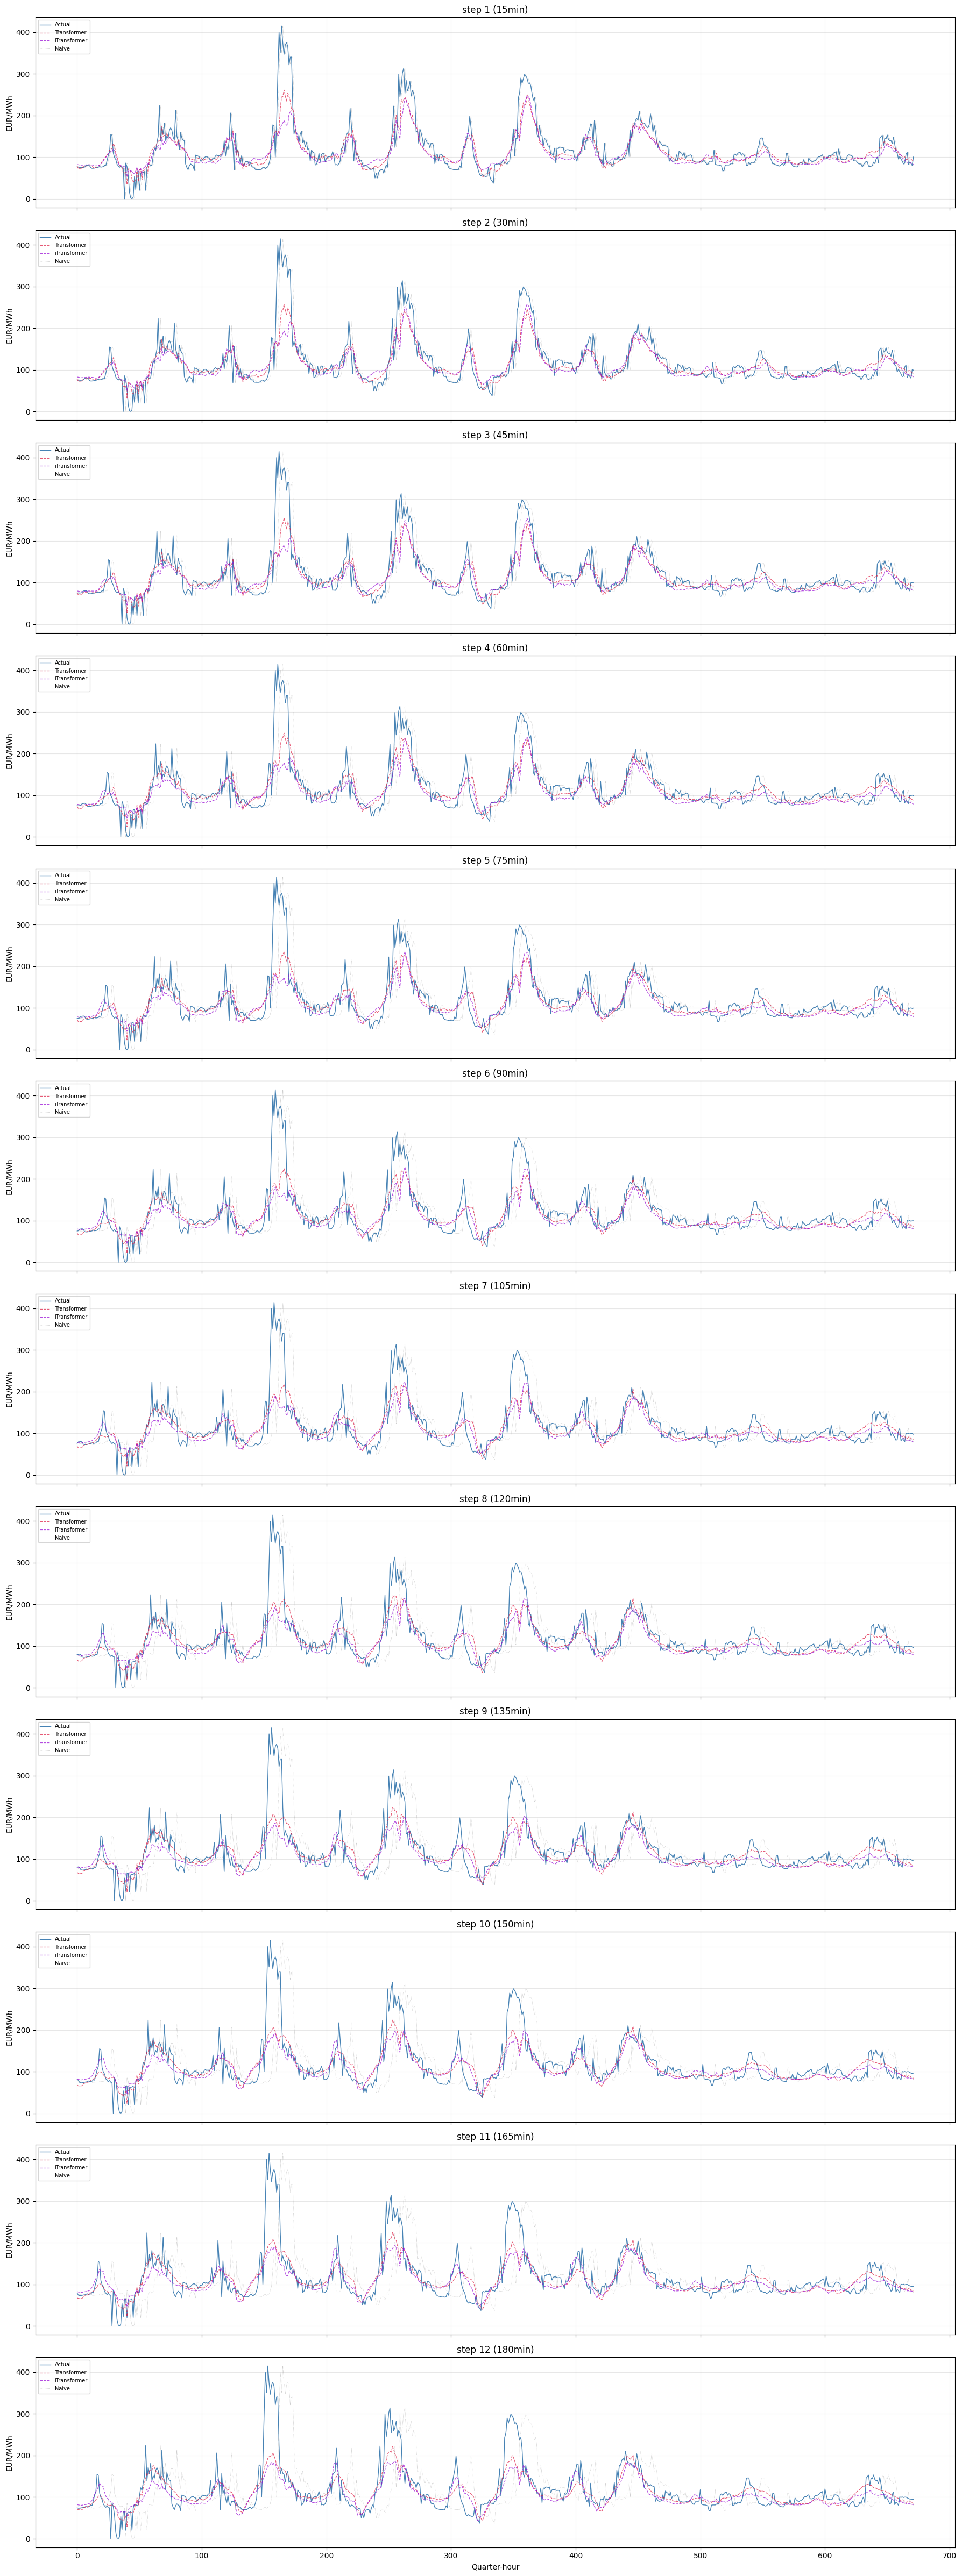

In [ ]:
N_PLOT = 96 * 7
colors = {'Transformer': 'crimson', 'iTransformer': 'darkviolet'}

fig, axes = plt.subplots(12, 1, figsize=(18, 48), sharex=True)
for h, ax in enumerate(axes):
    ax.plot(acts_tf[-N_PLOT:, h], color='steelblue', linewidth=1, label='Actual')
    for name, preds in results.items():
        ax.plot(preds[-N_PLOT:, h], color=colors[name], linewidth=0.9,
                linestyle='--', alpha=0.7, label=name)
    ax.plot(naive_vals[-N_PLOT:], color='gray', linewidth=0.6,
            linestyle=':', alpha=0.4, label='Naive')
    ax.set_ylabel('EUR/MWh')
    ax.set_title(f'step {h+1} ({(h+1)*15}min)')
    ax.legend(loc='upper left', fontsize=7); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Quarter-hour')
plt.tight_layout(); plt.show()



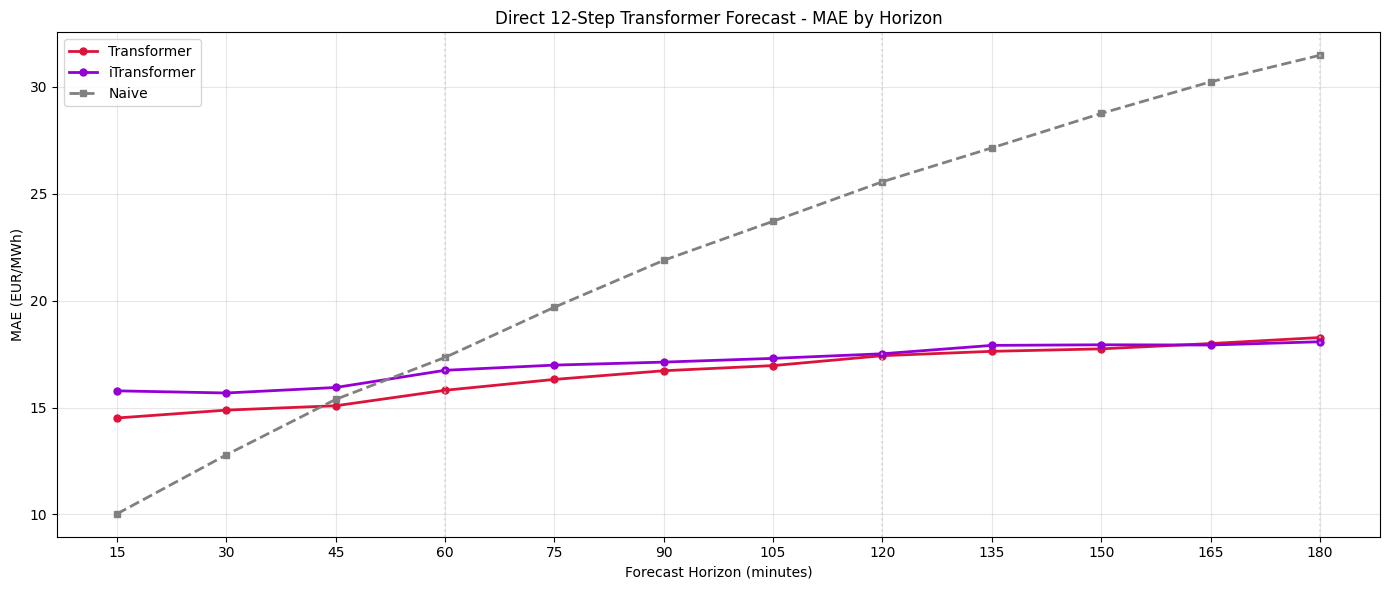

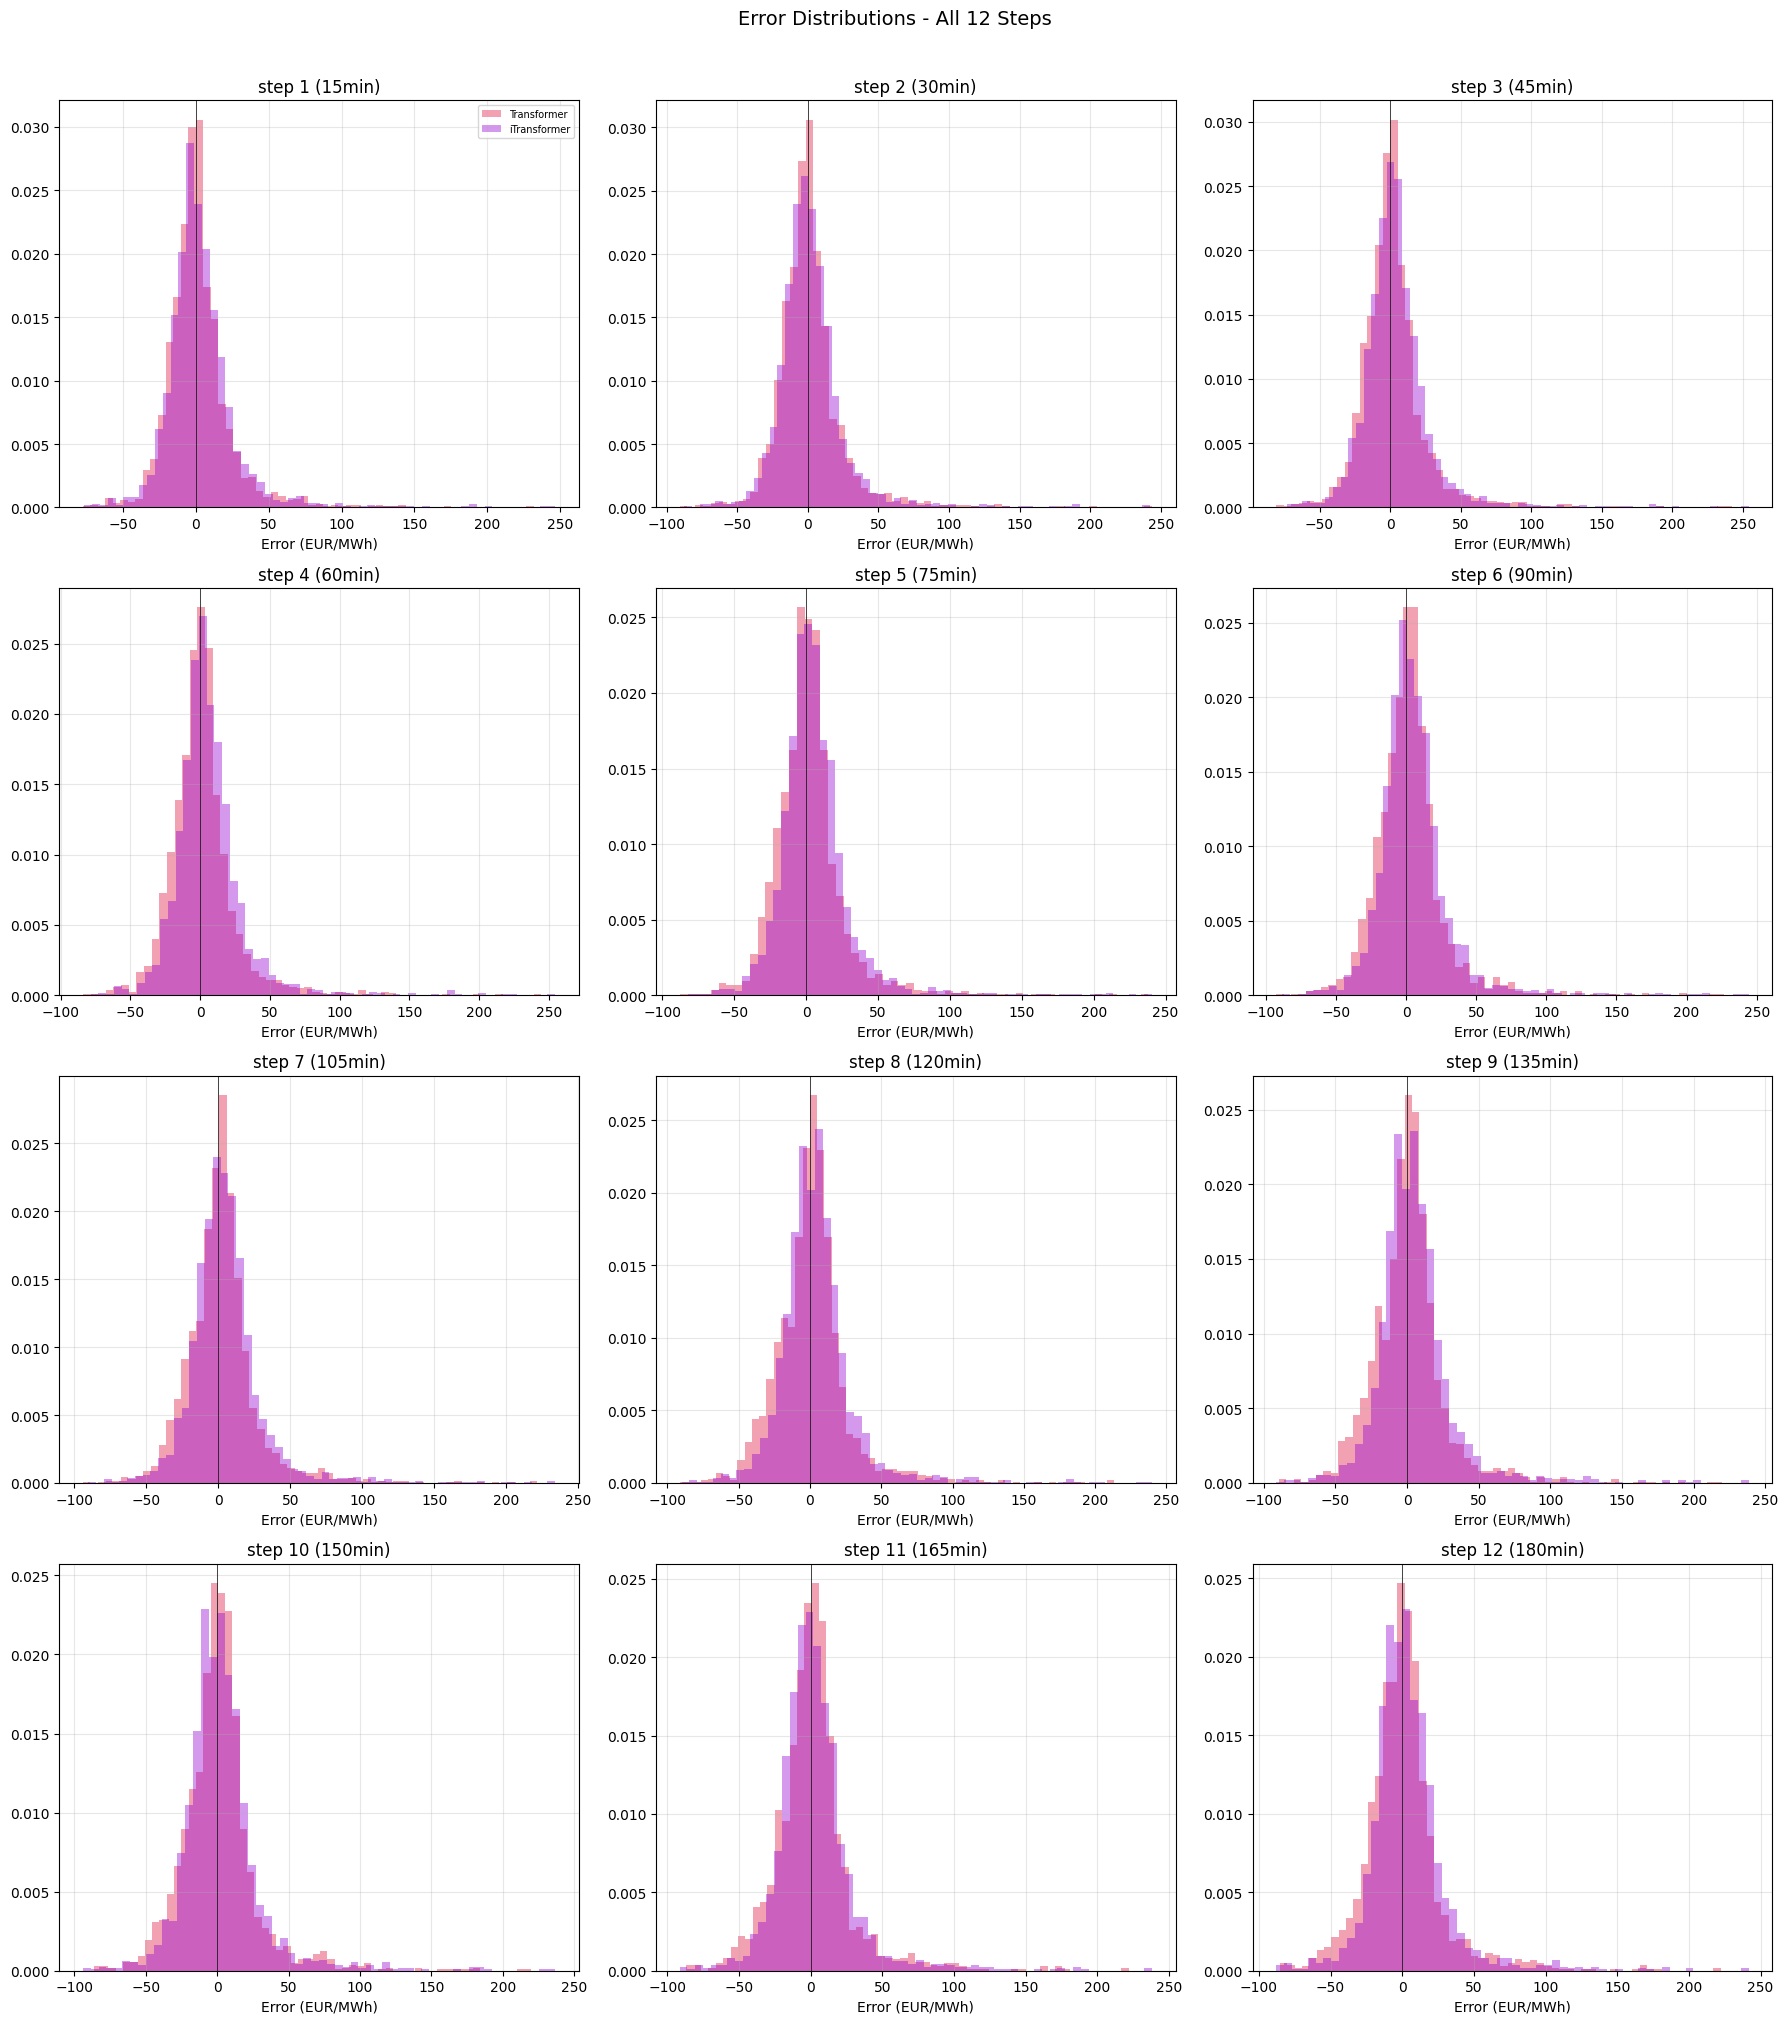

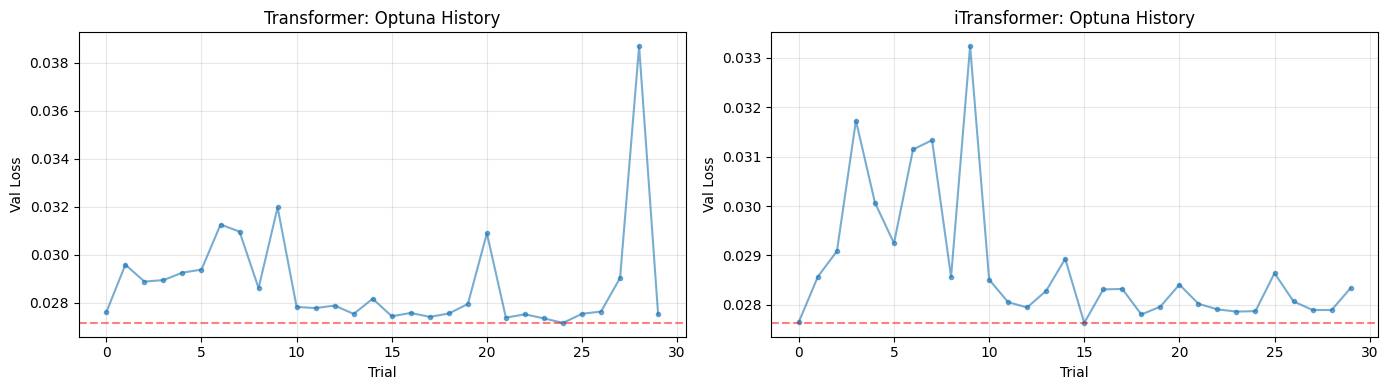

Transformer best params: {'lookback': 48, 'd_model': 32, 'nhead': 4, 'n_layers': 2, 'dim_ff': 128, 'lr': 0.0008127122658458551, 'dropout': 0.3}
iTransformer best params: {'lookback': 48, 'd_model': 32, 'nhead': 4, 'n_layers': 3, 'dim_ff': 128, 'lr': 0.001757234235013428, 'dropout': 0.3}


In [ ]:
# Error accumulation plot
fig, ax = plt.subplots(figsize=(14, 6))
colors_plot = {'Transformer': 'crimson', 'iTransformer': 'darkviolet'}
steps = np.arange(1, HORIZON + 1)
minutes = steps * 15

for name, preds in results.items():
    acts = acts_tf[-n_test:] if name == 'Transformer' else acts_it[-n_test:]
    preds_c = preds[-n_test:]
    maes = [mean_absolute_error(acts[:, h], preds_c[:, h]) for h in range(HORIZON)]
    ax.plot(minutes, maes, 'o-', color=colors_plot[name], label=name, linewidth=2, markersize=5)

acts_ref = acts_tf[-n_test:]
naive_maes = [mean_absolute_error(acts_ref[:, h], naive_vals) for h in range(HORIZON)]
ax.plot(minutes, naive_maes, 's--', color='gray', label='Naive', linewidth=2, markersize=5)

for step_min in [60, 120, 180]:
    ax.axvline(step_min, color='lightgray', linestyle=':', alpha=0.7)

ax.set_xlabel('Forecast Horizon (minutes)')
ax.set_ylabel('MAE (EUR/MWh)')
ax.set_title('Direct 12-Step Transformer Forecast - MAE by Horizon')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xticks(minutes)
plt.tight_layout(); plt.show()

# Error distributions — all 12 steps
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
for h in range(HORIZON):
    ax = axes[h // 3, h % 3]
    for name, preds in results.items():
        acts = acts_tf[-n_test:] if name == 'Transformer' else acts_it[-n_test:]
        preds_c = preds[-n_test:]
        err = acts[:, h] - preds_c[:, h]
        ax.hist(err, bins=60, alpha=0.4, color=colors_plot[name], label=name, density=True)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title(f'step {h+1} ({(h+1)*15}min)')
    ax.set_xlabel('Error (EUR/MWh)')
    if h == 0: ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.suptitle('Error Distributions - All 12 Steps', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

# Optuna history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, study, name in zip(axes, [tf_study, it_study], ['Transformer', 'iTransformer']):
    vals = [t.value for t in study.trials if t.value and t.value < float('inf')]
    ax.plot(vals, 'o-', markersize=3, alpha=0.6)
    ax.axhline(min(vals), color='red', linestyle='--', alpha=0.5)
    ax.set_title(f'{name}: Optuna History'); ax.set_xlabel('Trial'); ax.set_ylabel('Val Loss')
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Transformer best params: {bp_tf}")
print(f"iTransformer best params: {bp_it}")



## 9. Summary

| Model | Type | Attention Over | Horizon | Output |
|---|---|---|---|---|
| **Transformer** | Encoder | Timesteps | 12 steps direct | All 12 simultaneously |
| **iTransformer** | Encoder (inverted) | Features | 12 steps direct | All 12 simultaneously |

Same architectures as the 3-horizon notebook — only `HORIZON=12` changed.
FC head outputs 12 values instead of 3. Compare with recursive transformer results to see direct vs sequential tradeoff.
